## Recommendation:

This program runs on ResNet18. Make sure you have the following equipped:

1. If you can enable T4 GPU or better, make sure you do. This program tends to stall when running on CPU

2. Feel Free to change the batch_sizes or num_workers values to increase effencieny

# Wildlife Photograph Analyzer:

This Program is designed to help create a basic model that identifies wildlife. This program uses a dataset from Kaggle of approximately ~1,500 different photos and approximately ~1,500 text files depiciting four animals: Zebra, Elephant, Rhino and Cape Buffalo. This program uses a pretrained model (Resnet) and Pytorch. For the sake of simplicity and the program's effeciency, this model has discarded the text files and focus on images instead. This model is divided into 7 Main Sections:

1. Imports

2. Data Cleaning and Preparation

3. Model Setup

4. Model Build

5. Training

6. Interference

7. Results.

There are notes within the file demonstrating purpose of code and reasoning behind certain actions (for example, the elimination of the text files)

## Imports

Here, everything tool that is needed will be imported here. Other Items may be imported throughout the algorithm, but the main necessities will be imported here.

In [ ]:
import numpy as np
import torch                                                                     # Necessary for running tools
import torchvision.models as models
import torchvision.transforms
import kagglehub
path = kagglehub.dataset_download("biancaferreira/african-wildlife")
print("Path to dataset files:", path)
import os
for root, dirs, files in os.walk(path):
  print(root, dirs, files)
print("Path to dataset files:", path)
from collections import Counter                                                  # Brought in for the purpose of counting images, due to an exact number being unknown from original dataset
import os
for animal_folder in os.listdir(path):
    folder_path = os.path.join(path, animal_folder)
    extensions = []
    for filename in os.listdir(folder_path):
      name, ext = os.path.splitext(filename)
      extensions.append(ext)
    print(animal_folder, Counter(extensions))
print("Path to dataset files:", path)

100%|██████████| 448M/448M [00:04<00:00, 97.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/biancaferreira/african-wildlife/versions/1
/root/.cache/kagglehub/datasets/biancaferreira/african-wildlife/versions/1 ['elephant', 'zebra', 'rhino', 'buffalo'] []
/root/.cache/kagglehub/datasets/biancaferreira/african-wildlife/versions/1/elephant [] ['301.jpg', '313.jpg', '165.jpg', '319.txt', '182.jpg', '020.jpg', '254.jpg', '272.jpg', '056.txt', '118.txt', '223.jpg', '011.jpg', '309.jpg', '152.jpg', '260.jpg', '279.jpg', '316.txt', '202.jpg', '283.txt', '303.txt', '303.jpg', '332.txt', '075.txt', '236.txt', '324.txt', '027.jpg', '217.jpg', '196.txt', '343.txt', '212.jpg', '085.txt', '090.txt', '371.jpg', '031.txt', '113.jpg', '246.txt', '083.txt', '234.jpg', '049.txt', '284.txt', '103.jpg', '069.txt', '179.jpg', '126.jpg', '160.jpg', '227.jpg', '144.txt', '341.txt', '323.jpg', '242.jpg', '356.txt', '094.jpg', '221.jpg', '363.jpg', '047.txt', '376.txt', '076.txt', '342.jpg', '330.jpg', '276.jpg', '060.jpg', '256.txt', '318.jpg', '

### Data Cleaning and Preperation

In [ ]:
from pathlib import Path
import shutil
source_root = Path(path)
dest_root = "clean data"
valid_extensions = [".jpg", ".JPG"]
for animal_folder in os.listdir(source_root):
  source_folder = os.path.join(source_root, animal_folder)
  dest_folder = os.path.join(dest_root, animal_folder)

  os.makedirs(dest_folder, exist_ok=True)

  for filename in os.listdir(source_folder):
    name, ext = os.path.splitext(filename)
    if ext in valid_extensions:
      source_file = os.path.join(source_folder, filename)
      dest_file = os.path.join(dest_folder, filename)
      shutil.copyfile(source_file, dest_file)

## Setup

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms                                     #Section Covers

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([transforms.RandomResizedCrop(IMG_SIZE), transforms.RandomHorizontalFlip(),transforms.ToTensor(),transforms.Normalize(MEAN, STD),])

val_transforms = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),transforms.ToTensor(),transforms.Normalize(MEAN, STD),])

Using device: cuda


In [ ]:
full_dataset = datasets.ImageFolder(dest_root, transform=train_transforms)
class_names = full_dataset.classes
print("Classes:", class_names)

Classes: ['buffalo', 'elephant', 'rhino', 'zebra']


## Build

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

for param in model.parameters():
  param.requires_grad = False
for param in model.fc.parameters():
  param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 60.9MB/s]


## Training

In [ ]:
val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset = datasets.ImageFolder(dest_root, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

def train_one_epoch(model, loader, criterion, optimizer):
  model.train()
  running_loss, correct, total = 0.0, 0, 0
  for images, labels in loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * images.size(0)
    _, preds = torch.max(outputs, 1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)
  return running_loss / total, correct / total                                   # Extra code was here, and was the cause of one of the breaks.

def evaluate(model, loader, criterion, optimizer):
  model.eval()
  running_loss, correct, total = 0.0, 0, 0
  for images, labels in loader:
      images, labels = images.to(device), labels.to(device)                     #
      outputs = model(images)
      loss = criterion(outputs, labels)

      running_loss += loss.item() * images.size(0)
      _, preds = torch.max(outputs, 1)
      correct += (preds == labels).sum().item()
      total += labels.size(0)
  return running_loss / total, correct / total

NUM_EPOCHS = 5
for epoch in range(NUM_EPOCHS):
  train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
  val_loss, val_acc = evaluate(model, val_loader, criterion, optimizer)
  print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train loss {train_loss:.3f} acc {train_acc:.3f} | "
        f"val loss {val_loss:.3f} acc {val_acc:.3f}")


Epoch 1/5 | train loss 1.039 acc 0.613 | val loss 0.577 acc 0.883
Epoch 2/5 | train loss 0.530 acc 0.890 | val loss 0.359 acc 0.933
Epoch 3/5 | train loss 0.409 acc 0.888 | val loss 0.290 acc 0.930
Epoch 4/5 | train loss 0.324 acc 0.913 | val loss 0.227 acc 0.953
Epoch 5/5 | train loss 0.297 acc 0.922 | val loss 0.206 acc 0.957


## Interference

In [ ]:
from PIL import Image

def identify_animal(image_path, model=model, transform=val_transforms, class_names=class_names):
  model.eval()
  image = Image.open(image_path).convert("RGB")
  input_tensor = transform(image).unsqueeze(0).to(device)

  with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)[0]
    pred_idx = torch.argmax(probs.item())

  print(f"Prediction: {class_names[pred_idx]} ({probs[pred_idx]*100:.1f}% confidence)")
  return class_names[pred_idx]

## Results

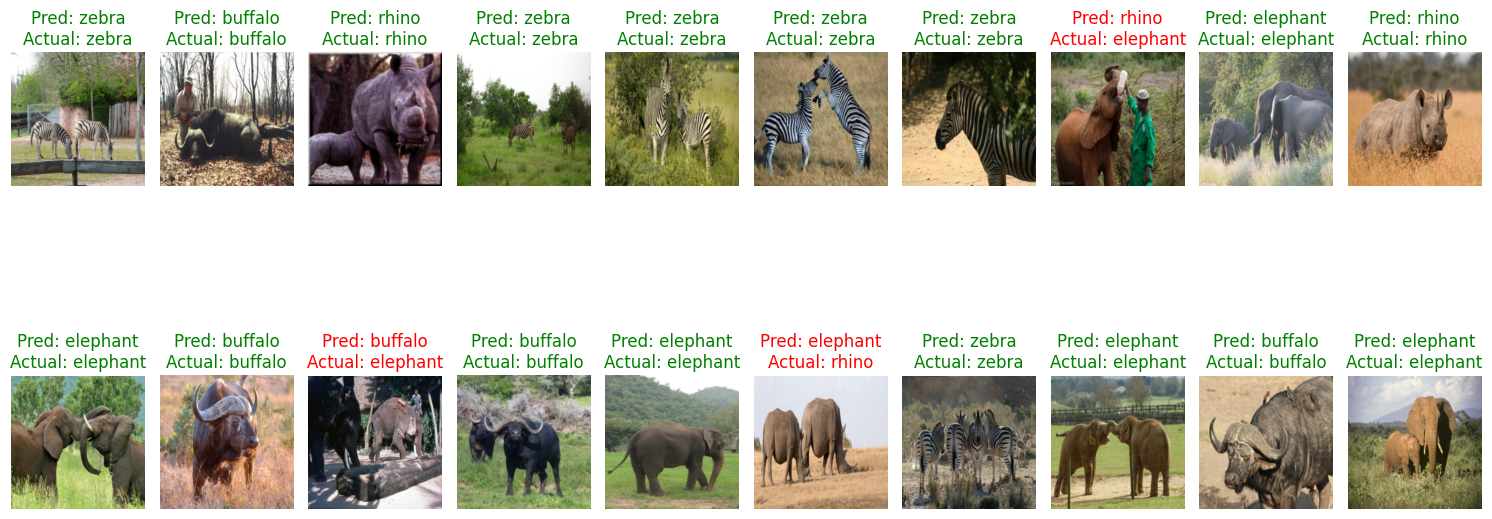

In [ ]:
import matplotlib.pyplot as plt
from math import ceil

def show_predictions(model, dataset, class_names, num_images =20) :
  model.eval()
  fig, axs = plt.subplots(2, ceil(num_images / 2), figsize=(15, 8))
  axs = axs.flatten()

  indices = torch.randperm(len(dataset))[:num_images]

  with torch.no_grad():
    for i, idx in enumerate(indices):
      image, true_label = dataset[idx]
      input_tensor = image.unsqueeze(0).to(device)

      output = model(input_tensor)
      probs = torch.softmax(output, dim=1)[0]
      pred_idx = torch.argmax(probs).item()


      img_display = image.permute(1, 2, 0).numpy()
      img_display = img_display * STD + MEAN
      img_display = img_display.clip(0, 1)

      axs[i].imshow(img_display)
      axs[i].axis("off")
      correct = pred_idx == true_label
      color = "green" if correct else "red"
      axs[i].set_title(
          f"Pred: {class_names[pred_idx]}\nActual: {class_names[true_label]}",
          color=color, fontsize=12
      )

  plt.tight_layout()
  plt.show()

show_predictions(model, val_dataset, class_names)